# Video Anomaly Detection on UCF-Crime

This notebook reproduces the main results from our two-stream Multiple Instance Learning (MIL) approach for weakly-supervised video anomaly detection on the UCF-Crime dataset.

## Architecture Overview

Our pipeline consists of:
1. **Two-Stream Feature Extraction**: R3D-18 backbones (pre-trained on Kinetics-400) extract 512-D features from RGB frames and Sobel motion gradients
2. **MIL Aggregation**: Temporal attention networks process video-level bags of features with ranking loss
3. **Late Fusion**: Weighted combination of RGB and motion anomaly scores

## Setup

This project uses `uv` for dependency management. To install:

```bash
uv sync
```

## Notes
In production, all model training and evaluation are performed on GPU nodes of the HPC cluster for efficiency. However, due to connection limitations, this notebook runs on the login node with CPU only. As a result, some steps may be slower and certain large-scale experiments (e.g., full R3D training) are omitted.

While functions and methods used in this notebook are defined in the codebase, we re-implement key steps here for clarity and reproducibility - in a simplified manner. This ensures each part of the workflow is transparent and easy to follow for the reader.

In [21]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve

# Project imports
from src.models.mil import MILModel
from src.utils.logger import get_logger

# Set plotting style
sns.set_style("whitegrid")
sns.set_palette("muted")

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger = get_logger("demo")
logger.info(f"Using device: {DEVICE}")

[2025-12-05 22:26:17] demo - INFO - Using device: cpu


## Configuration

Paths to pre-trained checkpoints and pre-extracted features.

## Data Access Note

**For Reviewers:** This notebook requires access to pre-trained models and features stored on DTU HPC.

**To request access:** Email s225224@dtu.dk or call 42426134 with your HPC username (your DTU ID, e.g., `s123456`, or if you are a teacher, you might have a fancier shorter one). We will grant access ASAP.

Access will be granted to:
- Models: `/work3/s225224/ucf-crime/checkpoints/`
- Features: `/work3/s225224/ucf-crime/features/`
- Dataset: `/work3/s225224/ucf-crime/data`

### To find your username:
```bash
# SSH into DTU HPC
ssh yourusername@login.hpc.dtu.dk

# Once logged in, run:
whoami
```

### Alternative for course groups:
If you're reviewing this and you are in a group that you can safely add to, you can alternatively add `s225224` to your course group, and we'll use group-based permissions. This is often simpler for multiple reviewers.

In [22]:
# CHECKPOINTS
RGB_MIL_CHECKPOINT = (
    "/work3/s225224/ucf-crime/checkpoints/mil/mil_rgb_20251204_130129/best_model.pth"
)
MOTION_MIL_CHECKPOINT = (
    "/work3/s225224/ucf-crime/checkpoints/mil/mil_motion_20251204_130253/best_model.pth"
)

# FEATURES (Pre-extracted from R3D backbones)
RGB_TEST_FEATURES_DIR = Path("/work3/s225224/ucf-crime/features/rgb_old2/Test")
MOTION_TEST_FEATURES_DIR = Path("/work3/s225224/ucf-crime/features/motion/Test")

RGB_TRAIN_FEATURES_DIR = Path("/work3/s225224/ucf-crime/features/rgb_old2/Train")
MOTION_TRAIN_FEATURES_DIR = Path("/work3/s225224/ucf-crime/features/motion/Train")

# GROUND TRUTH
ANNOTATION_FILE = (
    "/work3/s225224/ucf-crime/data/Temporal_Anomaly_Annotation_for_Testing_Videos.txt"
)

# SETTINGS
INPUT_DIM = 512
STRIDE = 16

## Load Pre-trained Models

Load the RGB and Motion MIL models from checkpoints.

In [23]:
def load_mil_model(checkpoint_path, input_dim, device):
    """Load a MIL model from checkpoint."""
    model = MILModel(input_dim=input_dim).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=True)

    if "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)

    model.eval()
    return model


# Load models
logger.info("Loading RGB MIL model...")
rgb_model = load_mil_model(RGB_MIL_CHECKPOINT, INPUT_DIM, DEVICE)

logger.info("Loading Motion MIL model...")
motion_model = load_mil_model(MOTION_MIL_CHECKPOINT, INPUT_DIM, DEVICE)

logger.info(f"Models loaded on {DEVICE}")

[2025-12-05 22:26:17] demo - INFO - Loading RGB MIL model...
[2025-12-05 22:26:17] demo - INFO - Loading Motion MIL model...
[2025-12-05 22:26:17] demo - INFO - Models loaded on cpu


## Frame-Level Evaluation

Evaluate MIL models on the test set using frame-level AUC. This measures how well the model localizes anomalies temporally within videos.

In [24]:
def parse_annotations(annotation_path):
    """Parse UCF-Crime temporal annotation file."""
    gt_intervals = {}
    with open(annotation_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 6:
                video_name = parts[0].replace(".mp4", "")
                intervals = []
                try:
                    # Format: video_name category start1 end1 start2 end2
                    s1, e1, s2, e2 = map(int, parts[2:6])
                    if s1 != -1:
                        intervals.append((s1, e1))
                    if s2 != -1:
                        intervals.append((s2, e2))
                    gt_intervals[video_name] = intervals
                except ValueError:
                    continue
    return gt_intervals


def create_gt_mask(total_frames, intervals):
    """Create binary ground truth mask for a video."""
    mask = np.zeros(total_frames, dtype=np.int32)
    for start, end in intervals:
        s = max(0, start)
        e = min(total_frames, end)
        if s < e:
            mask[s:e] = 1
    return mask


def get_video_scores(model, features_dir, device):
    """Run MIL inference on all test videos."""
    video_scores = {}
    feature_files = sorted(features_dir.glob("*.npy"))

    for feat_path in tqdm(feature_files, desc="Processing videos"):
        video_name = feat_path.stem
        features = np.load(feat_path)
        features_tensor = torch.from_numpy(features).float().to(device)

        with torch.no_grad():
            scores = model(features_tensor.unsqueeze(0))
            scores = scores.squeeze().cpu().numpy()

        # Upsample scores to frame-level (each clip = STRIDE frames)
        frame_scores = np.repeat(scores, STRIDE)
        video_scores[video_name] = frame_scores

    return video_scores


def compute_frame_level_auc(video_scores, gt_intervals):
    """Compute frame-level AUC across all annotated videos."""
    all_scores = []
    all_labels = []

    for video_name, scores in video_scores.items():
        if video_name not in gt_intervals:
            continue

        intervals = gt_intervals[video_name]
        total_frames = len(scores)
        gt_mask = create_gt_mask(total_frames, intervals)

        # Align lengths
        min_len = min(len(scores), len(gt_mask))
        all_scores.extend(scores[:min_len])
        all_labels.extend(gt_mask[:min_len])

    auc = roc_auc_score(all_labels, all_scores)
    return auc, np.array(all_labels), np.array(all_scores)


# Parse ground truth annotations
gt_intervals = parse_annotations(ANNOTATION_FILE)
logger.info(f"Loaded annotations for {len(gt_intervals)} videos")

[2025-12-05 22:26:17] demo - INFO - Loaded annotations for 290 videos


In [25]:
# Evaluate RGB MIL
logger.info("Evaluating RGB MIL model...")
rgb_scores = get_video_scores(rgb_model, RGB_TEST_FEATURES_DIR, DEVICE)
rgb_auc, rgb_labels, rgb_preds = compute_frame_level_auc(rgb_scores, gt_intervals)
logger.info(f"RGB MIL Frame-Level AUC: {rgb_auc:.4f}")

[2025-12-05 22:26:17] demo - INFO - Evaluating RGB MIL model...


Processing videos: 100%|██████████| 290/290 [00:00<00:00, 407.04it/s]


[2025-12-05 22:26:18] demo - INFO - RGB MIL Frame-Level AUC: 0.8133


In [26]:
# Evaluate Motion MIL
logger.info("Evaluating Motion MIL model...")
motion_scores = get_video_scores(motion_model, MOTION_TEST_FEATURES_DIR, DEVICE)
motion_auc, motion_labels, motion_preds = compute_frame_level_auc(motion_scores, gt_intervals)
logger.info(f"Motion MIL Frame-Level AUC: {motion_auc:.4f}")

[2025-12-05 22:26:18] demo - INFO - Evaluating Motion MIL model...


Processing videos: 100%|██████████| 290/290 [00:00<00:00, 400.70it/s]


[2025-12-05 22:26:18] demo - INFO - Motion MIL Frame-Level AUC: 0.7419


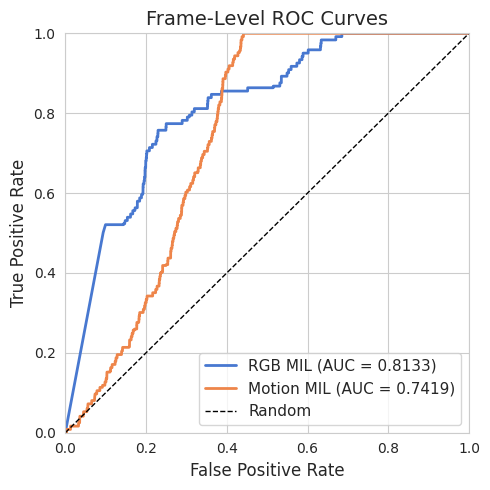

In [27]:
# Plot ROC curves
fig, ax = plt.subplots(figsize=(5, 5))

fpr_rgb, tpr_rgb, _ = roc_curve(rgb_labels, rgb_preds)
fpr_motion, tpr_motion, _ = roc_curve(motion_labels, motion_preds)

ax.plot(fpr_rgb, tpr_rgb, label=f"RGB MIL (AUC = {rgb_auc:.4f})", linewidth=2)
ax.plot(fpr_motion, tpr_motion, label=f"Motion MIL (AUC = {motion_auc:.4f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", label="Random", linewidth=1)

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Frame-Level ROC Curves", fontsize=14)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## Late Fusion + Weight Search

Combine RGB and Motion MIL scores with weighted fusion: `fused = α × RGB + (1-α) × Motion`. We sweep α from 0% to 100% to find the optimal fusion weight.

In [28]:
from scipy.ndimage import uniform_filter1d


def compute_fusion_auc(rgb_scores, motion_scores, gt_intervals, alpha):
    """Compute frame-level AUC for a given fusion weight."""
    all_preds = []
    all_labels = []

    # Find common videos
    common_videos = set(rgb_scores.keys()) & set(motion_scores.keys()) & set(gt_intervals.keys())

    for video_name in common_videos:
        scores_rgb = rgb_scores[video_name]
        scores_motion = motion_scores[video_name]

        # Align lengths
        min_len = min(len(scores_rgb), len(scores_motion))
        scores_rgb = scores_rgb[:min_len]
        scores_motion = scores_motion[:min_len]

        # Fuse scores
        fused = alpha * scores_rgb + (1 - alpha) * scores_motion
        fused = uniform_filter1d(fused, size=8, mode="nearest")

        # Get ground truth
        gt_mask = create_gt_mask(min_len, gt_intervals[video_name])

        all_preds.extend(fused)
        all_labels.extend(gt_mask)

    auc = roc_auc_score(all_labels, all_preds)
    return auc


# Sweep alpha values
alpha_values = np.arange(0.0, 1.05, 0.05)
results = []

logger.info("Running weight search...")
for alpha in tqdm(alpha_values, desc="Sweeping alpha"):
    auc = compute_fusion_auc(rgb_scores, motion_scores, gt_intervals, alpha)
    results.append({"alpha": alpha, "auc": auc})

# Find best
best_result = max(results, key=lambda x: x["auc"])
logger.info(f"Best fusion: alpha={best_result['alpha']:.2f} (RGB={best_result['alpha']*100:.0f}%) → AUC={best_result['auc']:.4f}")

[2025-12-05 22:26:19] demo - INFO - Running weight search...


Sweeping alpha: 100%|██████████| 21/21 [00:01<00:00, 16.39it/s]

[2025-12-05 22:26:20] demo - INFO - Best fusion: alpha=0.95 (RGB=95%) → AUC=0.8194


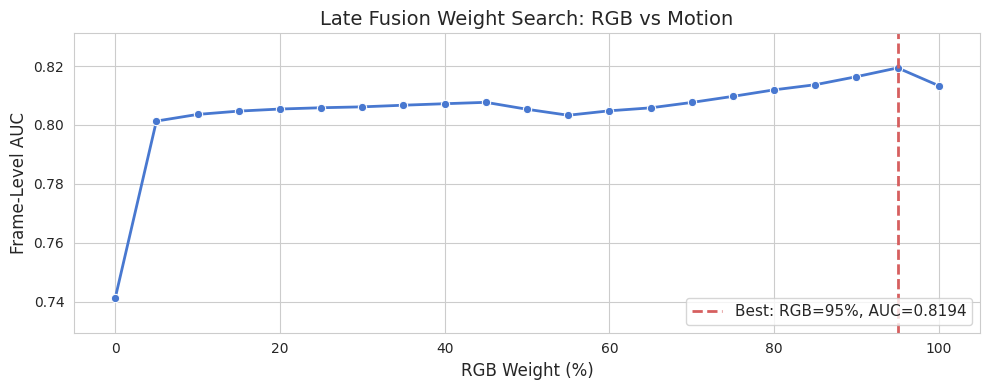

In [29]:
# Plot weight search results
alphas = np.array([r["alpha"] for r in results])
aucs = np.array([r["auc"] for r in results])
rgb_weights = alphas * 100

fig, ax = plt.subplots(figsize=(10, 4))

# Main line plot
sns.lineplot(x=rgb_weights, y=aucs, marker="o", linewidth=2, markersize=6, ax=ax)

# Best alpha vertical line
best_rgb_weight = best_result["alpha"] * 100
ax.axvline(
    x=best_rgb_weight,
    color=sns.color_palette("muted")[3],
    linestyle="--",
    linewidth=2,
    label=f"Best: RGB={best_rgb_weight:.0f}%, AUC={best_result['auc']:.4f}",
)

ax.set_xlabel("RGB Weight (%)", fontsize=12)
ax.set_ylabel("Frame-Level AUC", fontsize=12)
ax.set_title("Late Fusion Weight Search: RGB vs Motion", fontsize=14)
ax.legend(loc="lower right", fontsize=11)

# Adaptive y-axis
y_min, y_max = aucs.min(), aucs.max()
y_padding = (y_max - y_min) * 0.15
ax.set_ylim(y_min - y_padding, y_max + y_padding)

plt.tight_layout()
plt.show()

## MIL Retraining Demo

We demonstrate that the MIL model can be retrained from scratch using pre-extracted features. Since features are already extracted, training is fast (a few minutes on CPU). We set up a very simplified training setup and training script. For the full training script, we refer to `scripts/training/train_mil.py`

In [30]:
from src.models.mil import MILModel
from src.datasets.mil import MILDataLoader
from src.utils.losses import MILRankingLoss


train_loader = MILDataLoader(
    feature_dir=RGB_TRAIN_FEATURES_DIR,
    segments=32,
    shuffle=True,
    split="train",
    val_split=0.2,
)
val_loader = MILDataLoader(
    feature_dir=RGB_TRAIN_FEATURES_DIR,
    segments=32,
    shuffle=False,
    split="val",
    val_split=0.2,
)

logger.info(f"Train: {len(train_loader.normal_videos)} normal, {len(train_loader.anomaly_videos)} anomaly")
logger.info(f"Val: {len(val_loader.normal_videos)} normal, {len(val_loader.anomaly_videos)} anomaly")

# Training settings
NUM_EPOCHS = 50
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# Initialize fresh model
model_retrain = MILModel(input_dim=INPUT_DIM).to(DEVICE)
optimizer = torch.optim.AdamW(model_retrain.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = MILRankingLoss(lambda_1=0.01, lambda_2=0.01)

# Training history
train_losses = []
val_losses = []

logger.info("Starting MIL retraining...")
for epoch in range(NUM_EPOCHS):
    # Training
    model_retrain.train()
    epoch_losses = []

    for _ in range(20):
        normal_batch, anomaly_batch = train_loader.get_batch(BATCH_SIZE)  # ← FIX
        normal_batch = normal_batch.to(DEVICE)
        anomaly_batch = anomaly_batch.to(DEVICE)

        # Forward pass
        normal_scores = model_retrain(normal_batch)
        anomaly_scores = model_retrain(anomaly_batch)

        # Compute loss
        loss, _ = criterion(anomaly_scores, normal_scores)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_train_loss = np.mean(epoch_losses)
    train_losses.append(avg_train_loss)
    
    # Validation
    model_retrain.eval()
    val_epoch_losses = []
    with torch.no_grad():
        for _ in range(10):
            normal_batch, anomaly_batch = val_loader.get_batch(BATCH_SIZE)
            normal_batch = normal_batch.to(DEVICE)
            anomaly_batch = anomaly_batch.to(DEVICE)
            
            normal_scores = model_retrain(normal_batch)
            anomaly_scores = model_retrain(anomaly_batch)
            
            loss, _ = criterion(anomaly_scores, normal_scores)
            val_epoch_losses.append(loss.item())
    
    avg_val_loss = np.mean(val_epoch_losses)
    val_losses.append(avg_val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        logger.info(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

logger.info(f"Training complete. Final train loss: {train_losses[-1]:.4f}, Final val loss: {val_losses[-1]:.4f}")
logger.warning(
    "\nDEMONSTRATION - Simplified training loop\n\n"
    "Uses production MILModel and MILDataLoader but omits:\n"
    "  - Model checkpointing and early stopping\n"
    "  - Learning rate scheduling (CosineAnnealingLR)\n"
    "  - Training history tracking\n"
    "  - CUDA training on HPC with larger batches\n\n"
    "Full pipeline: src/scripts/training/train_mil.py\n"
)

[2025-12-05 22:26:20] src.datasets.mil - INFO - Loading MIL features from: /work3/s225224/ucf-crime/features/rgb_old2/Train (split=train)
[2025-12-05 22:26:22] src.datasets.mil - INFO - [TRAIN] Loaded 640 Normal videos, 646 Anomaly videos
[2025-12-05 22:26:22] src.datasets.mil - INFO - Loading MIL features from: /work3/s225224/ucf-crime/features/rgb_old2/Train (split=val)
[2025-12-05 22:26:22] src.datasets.mil - INFO - [VAL] Loaded 160 Normal videos, 161 Anomaly videos
[2025-12-05 22:26:22] demo - INFO - Train: 640 normal, 646 anomaly
[2025-12-05 22:26:22] demo - INFO - Val: 160 normal, 161 anomaly
[2025-12-05 22:26:22] demo - INFO - Starting MIL retraining...
[2025-12-05 22:26:24] demo - INFO - Epoch 1/50, Train Loss: 1.0568, Val Loss: 1.0071
[2025-12-05 22:26:31] demo - INFO - Epoch 5/50, Train Loss: 0.8597, Val Loss: 0.9897
[2025-12-05 22:26:40] demo - INFO - Epoch 10/50, Train Loss: 0.6734, Val Loss: 0.9280
[2025-12-05 22:26:49] demo - INFO - Epoch 15/50, Train Loss: 0.6169, Val Lo